# Parse nonb bed

## Description
This notebook is a playground to implement parsing Non-B DNA BED annotation files.

##  Table of Contents

- [References](#references)
- [Background](#background) 
- [Imports](#imports)
- [Datasets](#datasets)
- [Analysis](#analysis)
  - [Subsection 1](#subsection-1)
- [Conclusions](#conclusions)


## References

Add here scripts, articles, notes and wiki pages associated with the current notebook


##  Background
The general idea of the pipeline is the following

- Parse each of the 8 BED files to:
  - Get all non-B types (one per file).
  - Get all non-B subtypes (column name) for each type

- Run bedtools overlap to get hits on reference
- Filter hits based on quality criteria
  - NBD motif is fully included in exons? introns? gene body?
- Extract meaningful statistics
  - Number of total NBD structures
  - Number of total NBD structures by type
  - Coverage of NBD structures
  - Coverage of NBD structures by type
  - Diversity of NBD structures (number of different types)
- Perform statistic analyses 

### Bed file
The expected field in the bed file follow BED9 specification
1. chrom
2. start
3. end
4. name
5. score (empty)
6. strand
7. start (for browser)
8. end (for browser)
9. rgb (for browser)


# Snakemake pipeline to explore non-B DNA structures in coding vs non coding genes and transcripts

## Context

I want to build a Snakemake pipeline to analyze the presence of non-B DNA structures in the body of genes producing coding and non-coding transcripts, with the objective to analyze possible differences between these two groups. The outline is the following:

The general idea of the pipeline is the following

1. Parse each of the 8 BED files to:
  - Get all non-B types (one per file).
  - Get all non-B subtypes (column name) for each type
2. Run bedtools overlap to get hits on reference
3. Filter hits based on quality criteria
  - NBD motif is fully included in exons? introns? gene body?
4. Extract meaningful statistics
  - Number of total NBD structures
  - Number of total NBD structures by type
  - Coverage of NBD structures
  - Coverage of NBD structures by type
  - Diversity of NBD structures (number of different types)
5. Perform statistic analyses

## Data
The data I currently have is:
- BED annotation files for 8 different types of non-B DNA
- GTF annotation of the Human genome
- FASTA files of all Human transcripts
- FASTA files of all coding and lncRNA Human transcripts

You may include, request or produce any additional data needed.

## Instructions
1. Analyze the problem thoroughly and make an execution plan.
2. Present the plan to me and suggest working on a small subpart.
3. We will perform several iterations on each subpart until I validate it works, it's optimal, and it is properly explained and justified.
4. We will move to the next subpart.

In [ ]:
import os
from pathlib import Path
str(Path(__file__) / "workflow" / "scripts")


NameError: name '__file__' is not defined

## Imports

In [ ]:
# Add all needed imports here
import pandas as pd
import numpy as np
import os
import gzip
from pathlib import Path


## Datasets

In [ ]:

BASE_DIR = "/mnt/cbib/LNClassifier/paper/"
NONB_RESOURCES = BASE_DIR + "resources/annotation/GRCh38_NonBDNA"
bed_files = list(Path(NONB_RESOURCES).glob("*.bed.gz"))
print(f"Found {len(bed_files)} BED files:")
for bed_file in bed_files:
    print(f"  - {bed_file.name}")

Found 8 BED files:
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.g4Discovery.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.TRI.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.IR.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.STR.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.Z.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.DR.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.APR.bed.gz
  - GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.MR.bed.gz


## Analyses

In [ ]:
for f in bed_files:
    with gzip.open(f, 'rt') as file:
        bed_df = pd.read_csv(file, sep="\t", header=None, names=["chrom", "start", "end", "name", "score", "strand"], usecols=[0,1,2,3,4,5])
        subtypes = bed_df['name'].value_counts()
        print(f"\nFile: {f.name}")
        print(f"\nNon-B Type: {f.name.rsplit('.')[2]}")
        print("Subtypes:")
        print(subtypes)



File: GCA_000001405.15_GRCh38_no_alt_analysis_set.g4Discovery.bed.gz

Non-B Type: g4Discovery
Subtypes:
name
GQ:HUNTER=2.0      13698
GQ:HUNTER=-2.0     13503
GQ:HUNTER=1.5       8220
GQ:HUNTER=-1.5      8206
GQ:HUNTER=1.52      7164
                   ...  
GQ:HUNTER=3.71         1
GQ:HUNTER=-3.85        1
GQ:HUNTER=3.84         1
GQ:HUNTER=-3.71        1
GQ:HUNTER=3.49         1
Name: count, Length: 458, dtype: int64

File: GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.TRI.bed.gz

Non-B Type: gfa
Subtypes:
name
TRI:10:1:1     47318
TRI:10:0:1     33424
TRI:11:1:1     26169
TRI:12:1:1     23059
TRI:11:0:1     22667
               ...  
TRI:12:4:9         1
TRI:12:4:12        1
TRI:17:3:6         1
TRI:47:3:2         1
TRI:59:0:1         1
Name: count, Length: 1372, dtype: int64

File: GCA_000001405.15_GRCh38_no_alt_analysis_set.gfa.IR.bed.gz

Non-B Type: gfa
Subtypes:
name
IR:6:1:1      866035
IR:6:3:1      757741
IR:6:4:1      711961
IR:6:2:1      709037
IR:6:0:1      693979
     

### Subsection 1

A short explanation of the subsection followed by some code

In [ ]:
overlap_toy = BASE_DIR + "nonb-pipeline/results/gtf_bed_isec_toy.bed"

In [ ]:
pc_id_file = BASE_DIR + "te_pipeline/results/te_analysis_flexible/annotation/pc_transcript_ids.txt"
lnc_id_file = BASE_DIR + "te_pipeline/results/te_analysis_flexible/annotation/lncrna_transcript_ids.txt"

pc_ids = set(pd.read_csv(pc_id_file, header=None)[0])
lnc_ids = set(pd.read_csv(lnc_id_file, header=None)[0])

In [ ]:
transcript_cols = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attributes']
nbd_cols = ['chrom', 'chrom_start', 'chrom_end', 'nbd_id', 'nbd_score', 'nbd_strand', 'thickStart', 'thickEnd', 'itemRgb']
combined_cols = transcript_cols + nbd_cols

df = pd.read_csv(overlap_toy, sep="\t", header=None)
df.columns = combined_cols
df = df[df["feature"] == "transcript"]
df["transcript_id"] = df['attributes'].str.extract(r'transcript_id "([^"]+)"')
df

,seqname,source,feature,start,end,score,strand,frame,attributes,chrom,chrom_start,chrom_end,nbd_id,nbd_score,nbd_strand,thickStart,thickEnd,itemRgb,transcript_id
2,chr22,HAVANA,transcript,10524345,10529164,.,-,.,"gene_id ""ENSG00000294541.1""; transcript_id ""EN...",chr22,10527681,10527704,GQ:HUNTER=1.7,61,+,10527681,10527704,"219,88,41",ENST00000724296.1
3,chr22,HAVANA,transcript,10524345,10529164,.,-,.,"gene_id ""ENSG00000294541.1""; transcript_id ""EN...",chr22,10527891,10527932,GQ:HUNTER=1.59,78,+,10527891,10527932,"219,88,41",ENST00000724296.1
9,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,10742215,10742243,GQ:HUNTER=1.61,55,+,10742215,10742243,"219,88,41",ENST00000779064.1
10,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,10742649,10742672,GQ:HUNTER=-2.91,107,-,10742649,10742672,"219,88,41",ENST00000779064.1
11,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,10747634,10747655,GQ:HUNTER=3.05,92,+,10747634,10747655,"219,88,41",ENST00000779064.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139055,chr22,HAVANA,transcript,50775771,50783600,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,50783354,50783371,GQ:HUNTER=-2.41,53,-,50783354,50783371,"219,88,41",ENST00000468451.1
139056,chr22,HAVANA,transcript,50775771,50783600,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,50783403,50783428,GQ:HUNTER=-1.56,59,-,50783403,50783428,"219,88,41",ENST00000468451.1
139057,chr22,HAVANA,transcript,50777660,50783630,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,50781883,50781907,GQ:HUNTER=-1.92,60,-,50781883,50781907,"219,88,41",ENST00000464740.1
139058,chr22,HAVANA,transcript,50777660,50783630,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,50783354,50783371,GQ:HUNTER=-2.41,53,-,50783354,50783371,"219,88,41",ENST00000464740.1


In [ ]:
# Count number of hits
df.groupby("transcript_id").size().reset_index(name='counts')
df["coding_class"] = 'other'
df.loc[df["transcript_id"].str.split('.').str[0].isin(pc_ids), "coding_class"] = 'coding'
df.loc[df["transcript_id"].str.split('.').str[0].isin(lnc_ids), "coding_class"] = 'lncRNA'
df["transcript_length"] = df["end"] - df["start"] + 1
df["nbd_length"] = df["chrom_end"] - df["chrom_start"] + 1
df

,seqname,source,feature,start,end,score,strand,frame,attributes,chrom,...,nbd_id,nbd_score,nbd_strand,thickStart,thickEnd,itemRgb,transcript_id,coding_class,transcript_length,nbd_length
2,chr22,HAVANA,transcript,10524345,10529164,.,-,.,"gene_id ""ENSG00000294541.1""; transcript_id ""EN...",chr22,...,GQ:HUNTER=1.7,61,+,10527681,10527704,"219,88,41",ENST00000724296.1,lncRNA,4820,24
3,chr22,HAVANA,transcript,10524345,10529164,.,-,.,"gene_id ""ENSG00000294541.1""; transcript_id ""EN...",chr22,...,GQ:HUNTER=1.59,78,+,10527891,10527932,"219,88,41",ENST00000724296.1,lncRNA,4820,42
9,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,...,GQ:HUNTER=1.61,55,+,10742215,10742243,"219,88,41",ENST00000779064.1,lncRNA,11036,29
10,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,...,GQ:HUNTER=-2.91,107,-,10742649,10742672,"219,88,41",ENST00000779064.1,lncRNA,11036,24
11,chr22,HAVANA,transcript,10742050,10753085,.,+,.,"gene_id ""ENSG00000301473.1""; transcript_id ""EN...",chr22,...,GQ:HUNTER=3.05,92,+,10747634,10747655,"219,88,41",ENST00000779064.1,lncRNA,11036,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139055,chr22,HAVANA,transcript,50775771,50783600,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,...,GQ:HUNTER=-2.41,53,-,50783354,50783371,"219,88,41",ENST00000468451.1,coding,7830,18
139056,chr22,HAVANA,transcript,50775771,50783600,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,...,GQ:HUNTER=-1.56,59,-,50783403,50783428,"219,88,41",ENST00000468451.1,coding,7830,26
139057,chr22,HAVANA,transcript,50777660,50783630,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,...,GQ:HUNTER=-1.92,60,-,50781883,50781907,"219,88,41",ENST00000464740.1,other,5971,25
139058,chr22,HAVANA,transcript,50777660,50783630,.,-,.,"gene_id ""ENSG00000079974.19""; transcript_id ""E...",chr22,...,GQ:HUNTER=-2.41,53,-,50783354,50783371,"219,88,41",ENST00000464740.1,other,5971,18


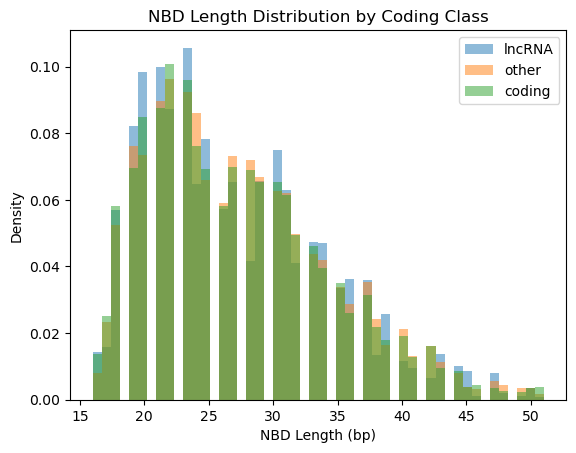

In [ ]:
# Create density plot of nbd_length by coding_class
import matplotlib.pyplot as plt

for coding_class in df['coding_class'].unique():
    data = df[df['coding_class'] == coding_class]['nbd_length']
    plt.hist(data, bins=50, alpha=0.5, label=coding_class, density=True)

plt.title('NBD Length Distribution by Coding Class')
plt.xlabel('NBD Length (bp)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
hits = df.groupby("transcript_id").agg(
    transcript_length=("transcript_length", "first"),
    coding_class=("coding_class", "first"),
    total_nbd_length=("nbd_length", "sum"),
    max_nbd_length=("nbd_length", "max"),
    g4_hit_count=("chrom", "size"),
)

hits["g4_coverage"] = hits["total_nbd_length"] / hits["transcript_length"]
hits

,transcript_length,coding_class,total_nbd_length,max_nbd_length,g4_hit_count,g4_coverage
transcript_id,,,,,,
ENST00000006251.11,60624,coding,1858,42,68,0.030648
ENST00000008876.7,10849,other,846,43,28,0.077980
ENST00000043402.8,26904,coding,1396,39,55,0.051888
ENST00000086933.3,3300,coding,79,31,3,0.023939
ENST00000155674.9,27777,coding,231,39,9,0.008316
...,...,...,...,...,...,...
ENST00000849655.1,10527,lncRNA,19,19,1,0.001805
ENST00000850559.1,39637,coding,407,38,15,0.010268
ENST00000850560.1,43509,other,430,38,16,0.009883


In [ ]:
# Summarize hits by coding class
hits.groupby("coding_class")["g4_hit_count"].describe()
print("\nG4 Hit Summary:")
print(hits.groupby("coding_class")["g4_hit_count"].describe())

print("\nG4 Max length Summary:")
print(hits.groupby("coding_class")["max_nbd_length"].describe())

print("\nG4 Overlap Summary:")
print(hits.groupby("coding_class")["total_nbd_length"].describe())

print("\nG4 Coverage Summary:")
print(hits.groupby("coding_class")["g4_coverage"].describe())


G4 Hit Summary:
               count       mean        std  min  25%   50%   75%    max
coding_class                                                           
coding        2279.0  21.390522  28.500515  1.0  6.0  12.0  25.0  339.0
lncRNA        3485.0  13.296413  17.728764  1.0  3.0   7.0  17.0  205.0
other         1341.0   9.581655  13.674694  1.0  2.0   5.0  11.0  184.0

G4 Max length Summary:
               count       mean       std   min   25%   50%   75%   max
coding_class                                                           
coding        2279.0  39.343133  6.735231  16.0  35.0  40.0  44.0  51.0
lncRNA        3485.0  36.987948  7.703934  16.0  31.0  38.0  43.0  51.0
other         1341.0  35.577927  7.851661  16.0  30.0  36.0  42.0  51.0

G4 Overlap Summary:
               count        mean         std   min    25%    50%    75%  \
coding_class                                                              
coding        2279.0  581.787626  779.984144  16.0  168.5  322.0  67

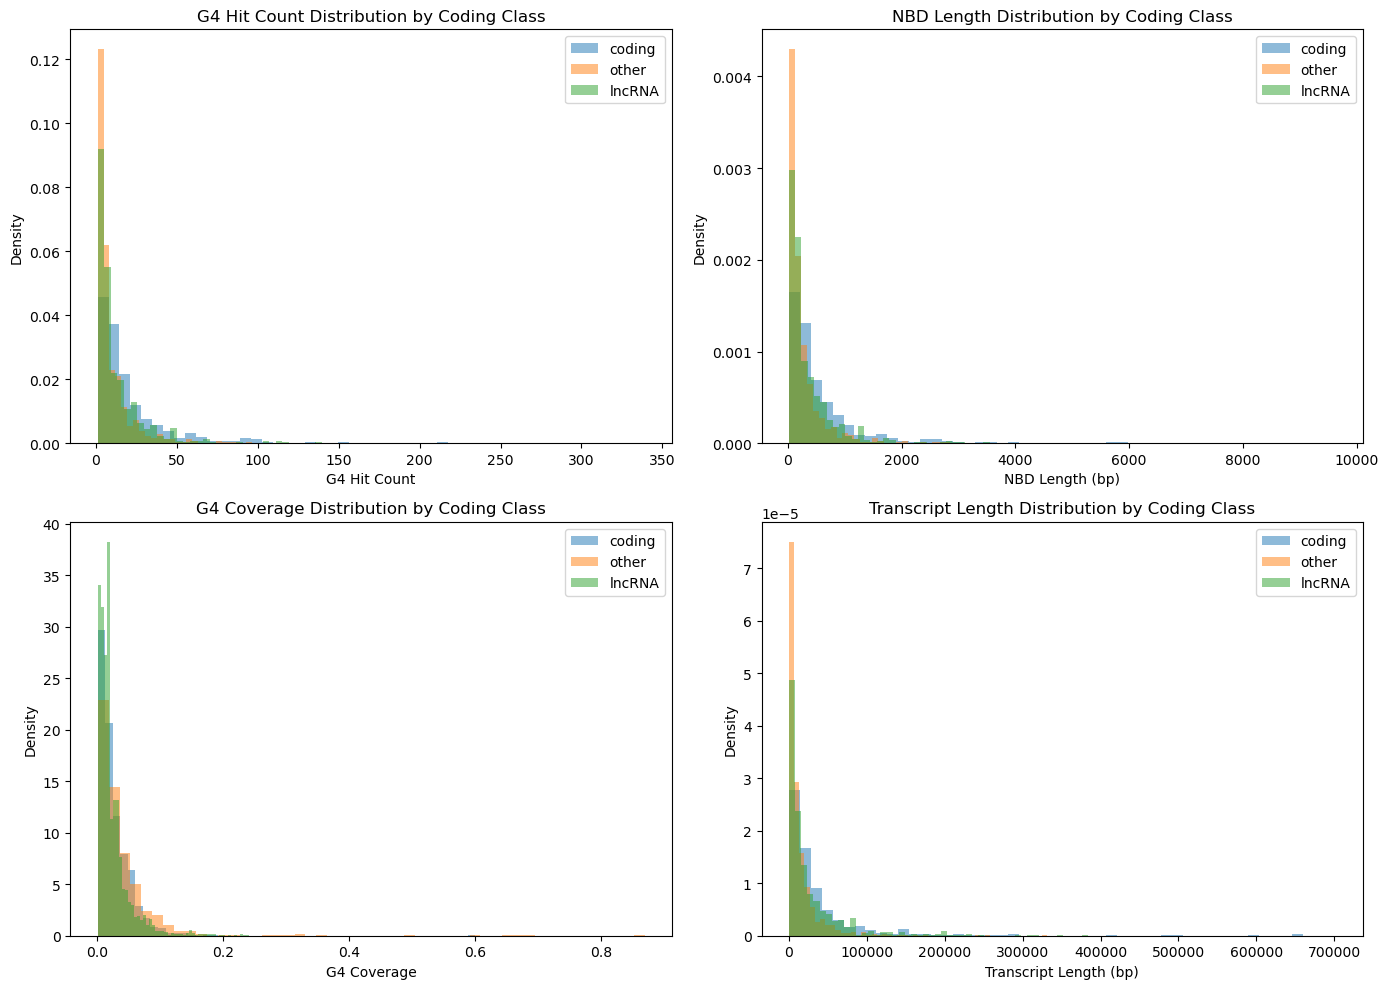

In [ ]:
import matplotlib.pyplot as plt

# Create figure with subplots for different metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of G4 hit counts by coding class
for coding_class in hits['coding_class'].unique():
    data = hits[hits['coding_class'] == coding_class]['g4_hit_count']
    axes[0, 0].hist(data, bins=50, alpha=0.5, label=coding_class, density=True)
axes[0, 0].set_title('G4 Hit Count Distribution by Coding Class')
axes[0, 0].set_xlabel('G4 Hit Count')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# Plot 2: Distribution of NBD length by coding class
for coding_class in hits['coding_class'].unique():
    data = hits[hits['coding_class'] == coding_class]['nbd_length']
    axes[0, 1].hist(data, bins=50, alpha=0.5, label=coding_class, density=True)
axes[0, 1].set_title('NBD Length Distribution by Coding Class')
axes[0, 1].set_xlabel('NBD Length (bp)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# Plot 3: Distribution of G4 coverage by coding class
for coding_class in hits['coding_class'].unique():
    data = hits[hits['coding_class'] == coding_class]['g4_coverage']
    axes[1, 0].hist(data, bins=50, alpha=0.5, label=coding_class, density=True)
axes[1, 0].set_title('G4 Coverage Distribution by Coding Class')
axes[1, 0].set_xlabel('G4 Coverage')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# Plot 4: Distribution of transcript length by coding class
for coding_class in hits['coding_class'].unique():
    data = hits[hits['coding_class'] == coding_class]['transcript_length']
    axes[1, 1].hist(data, bins=50, alpha=0.5, label=coding_class, density=True)
axes[1, 1].set_title('Transcript Length Distribution by Coding Class')
axes[1, 1].set_xlabel('Transcript Length (bp)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import time

# Benchmark runtime of code in for loop

for approach in ['extract', 'split']:
    start_time = time.time()
    for _ in range(10):
        if approach == 'extract':
            df["transcript_id"] = df[8].str.extract(r'transcript_id "([^"]+)"')
        elif approach == 'split':
            df["transcript_id"] = df[8].str.split(';').str[1].str.split('"').str[1]

    end_time = time.time()
    elapsed_time = end_time - start_time

    print(f"\nApproach: {approach}")
    print(f"\nTotal runtime: {elapsed_time:.2f} seconds")
    print(f"Average time per file: {elapsed_time/len(bed_files):.2f} seconds")


Approach: extract

Total runtime: 1.88 seconds
Average time per file: 0.23 seconds

Approach: split

Total runtime: 6.01 seconds
Average time per file: 0.75 seconds


## Conclusions

Explain what conclusions are drawn from this notebook